# Global preparations

In [10]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision.transforms.functional import to_pil_image
from tqdm.notebook import tqdm

torch.set_float32_matmul_precision('high')
import warnings
import torch._dynamo
torch._dynamo.config.cache_size_limit = 128
warnings.filterwarnings(
    "ignore",
    message=".*has_cuda.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_cudnn.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_mps.*deprecated.*"
)
warnings.filterwarnings(
    "ignore",
    message=".*has_mkldnn.*deprecated.*"
)

device = 'cuda:5'
summation_dtype = torch.float32
random_seed = 1
torch.manual_seed(random_seed)
np.random.seed(random_seed)
torch.backends.cudnn.enabled = True
print(torch.__version__)

2.1.2+cu121


# Text data preparation

Let's read small fineweb fragment

In [11]:
import gdown
url = 'https://drive.google.com/file/d/1vWjyIpU6wvCPtx2OdV_4M3MXX6FsOpxV/view'
output = 'fineweb_texts.txt'
if not os.path.exists(output):
    gdown.download(url, output, quiet=False, fuzzy=True)
size = os.path.getsize(output)
if size < 233 * 1024 * 1024:
    raise RuntimeError(f'Download failed: file size {size/1024/1024:.1f} MB')

In [12]:
CONTEXT_SIZE = 32
RAW_VOCAB_SIZE = 256
BOS_ID = RAW_VOCAB_SIZE  # 256
VOCAB_SIZE = RAW_VOCAB_SIZE + 1  # 257

In [13]:
TESTING_LENGTH = 10_000

from spiky.util.text_snippet_sampler import TextSnippetSampler

snippet_sampler = TextSnippetSampler(
    'fineweb_texts.txt',
    CONTEXT_SIZE,
    TESTING_LENGTH,
    device,
    random_seed=random_seed,
)

In [14]:
snippet_sampler.sample_training_batch(2)

tensor([[105, 111, 110,  46,  10,  67,  72,  65,  86,  69,  90,  32,  87,  65,
          83,  32,  73,  78,  83,  80,  73,  82,  69,  68,  32,  66,  89,  32,
          77,  65,  72,  65],
        [ 32,  54,  48,  44,  48,  48,  48,  45, 115, 116, 117, 100, 101, 110,
         116,  32,  80, 114, 105, 110,  99, 101, 115, 115,  32,  78, 111, 114,
          97,  32,  98, 105]], device='cuda:5', dtype=torch.int32)

In [15]:
batch = snippet_sampler.sample_training_batch(4)
batch.shape
snippet_sampler.batch_to_text(batch)

['tion song.\n- Then bring the Amma',
 'is a plant adviser, educator and',
 'on in the wild within 50 years,"',
 'd over glossy or smooth enamel p']

In [16]:
for test_batch in snippet_sampler.testing_batches_iterator(4):
    print(test_batch.shape)
    print(snippet_sampler.batch_to_text(test_batch))
    break

torch.Size([4, 32])
[' in enrollments than is evident ', 'hn Vidal discovers, other causes', ' giant pandas, polar bears, tige', 'ake part in the nomination of th']


# LUTTransformer (lutorch sketch)

In [127]:
# LUTTransformer sketch using lutorch: MultiHeadLut, LUTAttention
import torch.nn as nn
from dataclasses import dataclass
from spiky.lutorch.multi_head_lut import MultiHeadLut
from spiky.lutorch.lut_attention import LUTAttention, PairProcessingConfig, PairProcessingMode
from spiky.lutorch.lut_helpers import UncertaintyMode
from spiky.lutorch.multi_head_wta import WTA

class Reshape(nn.Module):
    def __init__(self, *shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return x.reshape(x.shape[0], *self.shape)

class Merge(nn.Module):
    def forward(self, x):
        B, H, E = x.shape
        return x.reshape(B * H, E)
    
class Unmerge(nn.Module):
    def __init__(self, H):
        super().__init__()
        self.H = H

    def forward(self, x):
        return x.reshape(x.shape[0] // self.H, self.H, *x.shape[1:])

@dataclass(frozen=True)
class LUTTransformerConfig:
    """Full configuration for LUTTransformer (embedding, layers, block params, temperatures)."""
    vocab_size: int = VOCAB_SIZE
    embedding_dim: int = 64
    num_layers: int = 6
    num_heads: int = 4
    hidden_dim_attn: int = 16
    hidden_dim_value: int = 256
    hidden_dim_ffn: int = 256
    n_anchor_pairs_attn: int = 10
    n_anchor_pairs_ffn: int = 12
    n_positional_buckets: int = 1
    tables_per_head_attn: int = 96
    tables_per_head_value: int = 96
    ffn_tables: int = 96
    dropout: float = 0.0
    smooth_mode: bool = False
    n_alternatives: int = 1
    device: object = device
    connected_anchors_mode: bool = False
    random_seed: object = 42
    attention_temperature: float = 0.25
    embedding_temperature: float = 0.1
    initial_weights_noise: float = 0.001
    normalise_weights: bool = False
    calibrate_output: bool = False
    uncertainty_mode: UncertaintyMode = UncertaintyMode.INVERSE_L1
    pair_config: PairProcessingConfig = PairProcessingConfig(c1=1.0, c2=-2.0)

    def __post_init__(self):
        assert (self.embedding_dim % self.num_heads) == 0

class LUTLinearReluPostProcessor(nn.Module):
    def __init__(self, num_heads, hdim, odim):
        super().__init__()
        self.pp = nn.Sequential(
            nn.ReLU(),
            Reshape(num_heads * hdim),
            nn.Linear(num_heads * hdim, num_heads * odim, device=device),
            Reshape(num_heads, odim)
        )

    def forward(self, x):
        return self.pp(x)
    
class LUTWTAPostProcessor(nn.Module):
    def __init__(self, num_heads, n_channels, hdim, odim, smooth_mode, n_alternatives, device):
        super().__init__()
        n_inputs = (num_heads * hdim) // n_channels
        self.pp = nn.Sequential(
            Reshape(n_channels, n_inputs),
            WTA(
                n_channels=n_channels,
                n_inputs=n_inputs,
                n_outputs=num_heads * odim,
                n_alternatives=n_alternatives,
                smooth_mode=smooth_mode,
                initial_weights_noise=0.001,
                normalize_weights=False,
                device=device
            ),
            Reshape(n_channels, num_heads, odim),
        )

    def forward(self, x):
        return self.pp(x).sum(dim=-3)


class LUTTransformer(nn.Module):
    """Transformer with lutorch primitives: MultiHeadLut + LUTAttention."""

    class Block(nn.Module):
        """Single transformer block: LUT cross-attention + value projection + FFN."""

        def __init__(self, c: LUTTransformerConfig):
            super().__init__()
            self.cross_attn = LUTAttention(
                MultiHeadLut(
                    input_dim=c.embedding_dim,
                    n_heads=c.num_heads,
                    n_outputs=1,
                    n_anchor_pairs=c.n_anchor_pairs_attn,
                    tables_per_head=c.tables_per_head_attn,
                    n_buckets=c.n_positional_buckets,
                    smooth_mode=c.smooth_mode,
                    n_alternatives=c.n_alternatives,
                    normalize_weights=c.normalise_weights,
                    calibrate_output=False,
                    device=c.device,
                    connected_anchors_mode=c.connected_anchors_mode,
                    random_seed=c.random_seed,
                    initial_weights_noise=c.initial_weights_noise,
                    uncertainty_mode=c.uncertainty_mode,
#                     n_post_processor_inputs=c.hidden_dim_attn,
#                     # post_processor=LUTLinearReluPostProcessor(c.num_heads, c.hidden_dim_attn, 1)
#                     post_processor=LUTWTAPostProcessor(
#                         c.num_heads, 4, c.hidden_dim_attn, 1,
#                         smooth_mode=c.smooth_mode,
#                         n_alternatives=c.n_alternatives,
#                         device=device
#                     )
                ),
                causal=True,
                include_diagonal=False,
                attention_temperature=c.attention_temperature,
                n_positional_buckets=c.n_positional_buckets,
                pair_config=c.pair_config,
            )
            self.value_lut = MultiHeadLut(
                input_dim=c.embedding_dim,
                n_heads=c.num_heads,
                n_outputs=c.embedding_dim // c.num_heads,
                n_anchor_pairs=c.n_anchor_pairs_attn,
                tables_per_head=c.tables_per_head_value,
                smooth_mode=c.smooth_mode,
                n_alternatives=c.n_alternatives,
                normalize_weights=c.normalise_weights,
                calibrate_output=c.calibrate_output,
                device=c.device,
                connected_anchors_mode=c.connected_anchors_mode,
                random_seed=c.random_seed,
                initial_weights_noise=c.initial_weights_noise,
                uncertainty_mode=c.uncertainty_mode,
#                 n_post_processor_inputs=c.hidden_dim_value,
#                 # post_processor=LUTLinearReluPostProcessor(c.num_heads, c.hidden_dim_value, c.embedding_dim // c.num_heads)
#                 post_processor=LUTWTAPostProcessor(
#                     c.num_heads, 16, c.hidden_dim_value, c.embedding_dim // c.num_heads,
#                     smooth_mode=c.smooth_mode,
#                     n_alternatives=c.n_alternatives,
#                     device=device
#                 )
            )
            self.attn_dropout = nn.Dropout(c.dropout)
            self.ffn = MultiHeadLut(
                input_dim=c.embedding_dim,
                n_heads=1,
                n_outputs=c.embedding_dim,
                n_anchor_pairs=c.n_anchor_pairs_ffn,
                tables_per_head=c.ffn_tables,
                smooth_mode=c.smooth_mode,
                n_alternatives=c.n_alternatives,
                normalize_weights=c.normalise_weights,
                calibrate_output=c.calibrate_output,
                device=c.device,
                connected_anchors_mode=c.connected_anchors_mode,
                random_seed=c.random_seed,
                initial_weights_noise=c.initial_weights_noise,
                uncertainty_mode=c.uncertainty_mode,
                n_post_processor_inputs=c.hidden_dim_ffn,
#                 # post_processor=LUTLinearReluPostProcessor(1, c.hidden_dim_ffn, c.embedding_dim)
#                 post_processor=LUTWTAPostProcessor(
#                     1, 16, c.hidden_dim_ffn, c.embedding_dim,
#                     smooth_mode=c.smooth_mode,
#                     n_alternatives=c.n_alternatives,
#                     device=device
#                 )
            )
            self.ffn_dropout = nn.Dropout(c.dropout)

        def forward(self, z):
            B, S, E = z.shape
            attn_weights = self.cross_attn(z, z)  # [B, S, S, H]
            v = self.value_lut(z.reshape(-1, E))  # [B*S, H, E//H]
            H = v.shape[1]
            v = v.reshape(B, S, H, -1)  # [B, S, H, E//H]
            attn_out = attn_weights.permute(0, 3, 1, 2) @ v.permute(0, 2, 1, 3)  # [B, H, S, E//H]
            attn_out = attn_out.permute(0, 2, 1, 3).reshape(B, S, E)  # [B, S, E]
            z = z + self.attn_dropout(attn_out)  # [B, S, E]
            ffn_out = self.ffn(z.reshape(-1, E)).reshape(B, S, -1)  # [B, S, E]
            z = z + self.ffn_dropout(ffn_out)  # [B, S, E]
            return z

    def __init__(self, c: LUTTransformerConfig = LUTTransformerConfig(), maxlen=CONTEXT_SIZE):
        super().__init__()
        self.config = c
        with torch.no_grad():
            self.token_embedder = nn.Embedding(c.vocab_size, c.embedding_dim // 2, device=c.device)
            self.token_embedder.weight.copy_(torch.randn(self.token_embedder.weight.shape, device=c.device) * 0.1)
            self.token_unembedder = nn.Embedding(c.vocab_size, c.embedding_dim, device=c.device)
            self.token_unembedder.weight.copy_(torch.randn(self.token_unembedder.weight.shape, device=c.device) * 0.1)
        self.layers = nn.ModuleList([LUTTransformer.Block(c) for _ in range(c.num_layers)])
        self.register_buffer("pos_emb", torch.randn([1, maxlen, c.embedding_dim // 2], device=device) * 0.1)


    def forward(self, tokens):
        z = self.token_embedder(tokens)  # [B, S, E]
        # z = z * torch.sign(self.pos_emb[:,:tokens.shape[1]])
        # z = z * torch.tanh(self.pos_emb[:,:tokens.shape[1]] * 10)
        # z = z * self.pos_emb[:,:tokens.shape[1]]
        z = torch.cat([z, self.pos_emb[:,:tokens.shape[1]].repeat(tokens.shape[0], 1, 1)], dim=-1)
        for layer in self.layers:
            z = layer(z)
        z = z / (z.norm(dim=-1, keepdim=True) + 1e-6)
        # logits = z @ self.token_unembedder.weight.T / self.config.embedding_temperature  # [B, S, E] @ [E, V] -> [B, S, V]
        logits = z @ self.token_unembedder.weight.T # [B, S, E] @ [E, V] -> [B, S, V]
        return logits

In [128]:
lut_transformer = None
optimizer = None
sched = None
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
lut_transformer = LUTTransformer()
print(lut_transformer)

LUTTransformer(
  (token_embedder): Embedding(257, 32)
  (token_unembedder): Embedding(257, 64)
  (layers): ModuleList(
    (0-5): 6 x Block(
      (cross_attn): LUTAttention(
        (multi_head_lut): MultiHeadLut(
          (lookup): AnchorPairsLookup()
          (projection): LProjection()
        )
      )
      (value_lut): MultiHeadLut(
        (lookup): AnchorPairsLookup()
        (projection): LProjection()
      )
      (attn_dropout): Dropout(p=0.0, inplace=False)
      (ffn): MultiHeadLut(
        (lookup): AnchorPairsLookup()
        (projection): LProjection()
      )
      (ffn_dropout): Dropout(p=0.0, inplace=False)
    )
  )
)


In [129]:
total = sum(p.numel() for p in lut_transformer.parameters())
trainable = sum(p.numel() for p in lut_transformer.parameters() if p.requires_grad)

print("total:", total)
print("trainable:", trainable)
print("frozen:", total - trainable)

total: 191127648
trainable: 191127648
frozen: 0


In [141]:
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

batch_size = 128
test_batch_size = 256

SCALE = 5.0
MAX_RATE = 0.01
def lr_func(t):
    return min(MAX_RATE, SCALE / (1 + t * batch_size)**0.5)

print(f"Crossover point for LR: {(SCALE / MAX_RATE )**2:,}")

lr = 0.00001
# optimizer = optim.SGD(lut_transformer.layers.parameters(), lr=lr)
# optimizer = optim.Adam(lut_transformer.layers.parameters(), lr=lr, weight_decay=3e-4)
# optimizer_embedder = optim.Adam(lut_transformer.token_embedder.parameters(), lr=lr, weight_decay=3e-4)
optimizer = optim.Adam(lut_transformer.parameters(), lr=lr)

n_steps=500000
# sched = LambdaLR(optimizer, lr_lambda=lr_func)
# sched_embedder = LambdaLR(optimizer_embedder, lr_lambda=lr_func)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=n_steps
)
# sched_embedder = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer_embedder, T_max=n_steps
# )

Crossover point for LR: 250,000.0


In [135]:
lut_train_losses = []
lut_test_losses = []

In [136]:
import torch
import torch.nn.functional as F


def generate_text_lut(lut_model, prefix, length, device):
    # Model operates on byte IDs; decode final byte stream as UTF-8 for display.
    # Position 0 = BOS; positions 1..CONTEXT_SIZE-1 = context. We right-align context so
    # position -1 always holds the last byte (matches training where last position = last preceding byte).
    ctx = list(prefix.encode("utf-8"))

    for _ in range(length):
        x = torch.zeros([1, CONTEXT_SIZE], dtype=torch.long, device=device)
        x[0, 0] = BOS_ID
        trunc_ctx = ctx[-(CONTEXT_SIZE - 1):]  # at most CONTEXT_SIZE-1 bytes so we never overwrite BOS
        if len(trunc_ctx) > 0:
            # Right-align: last byte of context at position -1 so logits[:, -1, :] is conditioned correctly
            x[0, -len(trunc_ctx):] = torch.tensor(trunc_ctx, dtype=torch.long, device=device)

        logits = lut_model(x)
        # Exclude BOS from sampling: generated stream should be UTF-8 bytes only.
        probs = torch.softmax(logits[:, -1, :RAW_VOCAB_SIZE], dim=-1)[0]
        next_id = torch.multinomial(probs, 1).item()
        ctx.append(next_id)

    ctx_bytes = [c for c in ctx if 0 <= c < 256]
    return bytes(ctx_bytes).decode("utf-8", errors="replace")

def evaluate_model(model, sampler, B):
    """Full-sequence mean cross-entropy loss (standard language modeling)."""
    model.eval()
    losses = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for batch in sampler.testing_batches_iterator(B):   # [B, C]
            # Prepend BOS at position 0
            inp = torch.empty(batch.shape[0], batch.shape[1], dtype=torch.long, device=batch.device)
            inp[:, 0] = BOS_ID
            inp[:, 1:] = batch[:, :-1].long()
            tgt = batch.long()

            logits = model(inp)   # [B, 32, 257]

            B_, T, V = logits.shape
            loss = F.cross_entropy(
                logits.reshape(B_ * T, V),
                tgt.reshape(B_ * T),
                reduction='mean',
            )
            losses.append(loss.item())

    # ---- small generation demo ----
    prefix = "Once upon a time "
    gen = generate_text_lut(model, prefix, length=80, device=device)
    print("\n[GEN]:", gen, "\n")

    model.train()
    return sum(losses) / len(losses) #  / (CONTEXT_SIZE * B)

In [137]:
test_loss = evaluate_model(lut_transformer, snippet_sampler, test_batch_size)
test_loss


[GEN]: Once upon a time ����-�rk�d�hzK�Vgo�bu[���~n*U`��>�tiT)+6����3P�lEhJR�S�Ѻ���'lZa��L�V 



5.555767166614532

In [ ]:
test_every=1000
train_loss = None
alpha = 0.01

pbar = tqdm(total=n_steps)
lut_transformer.train()

for step in range(n_steps):
    x = snippet_sampler.sample_training_batch(batch_size)   # [B, 32] bytes
    x = x.long() if x.dtype != torch.long else x
    inp = torch.empty(batch_size, x.shape[1], dtype=torch.long, device=x.device)
    inp[:, 0] = BOS_ID
    inp[:, 1:] = x[:, :-1]
    tgt = x

    logits = lut_transformer(inp)      # [B, C-1, 256]
    B, T, V = logits.shape

    # Train on full sequence with sum reduction (gradient from all positions)
    loss = F.cross_entropy(
        logits.reshape(B * T, V),
        tgt.reshape(B * T),
        reduction="mean",
    )

    optimizer.zero_grad()
    #optimizer_embedder.zero_grad()
    loss.backward()
    optimizer.step()
    #optimizer_embedder.step()
    sched.step()
    #sched_embedder.step()

    loss_value = loss.item()
    train_loss = loss_value if train_loss is None else (1 - alpha) * train_loss + alpha * loss_value
    pbar.update(1)
    if step % 10 == 0:
        pbar.set_description(f"loss={train_loss:.4f}, lr {sched.get_last_lr()[0]:.6f}")

    if step % test_every == 0:
        test_loss = evaluate_model(lut_transformer, snippet_sampler, test_batch_size)
        if len(lut_train_losses) == 0 or step > 0:
            lut_train_losses.append(train_loss)
            lut_test_losses.append(test_loss)
        print(f"[TEST] step {step}: loss={test_loss:.4f}")

  0%|          | 0/500000 [00:00<?, ?it/s]


[GEN]: Once upon a time every state we have two different and avoid attitude well. Therefore, more impor 

[TEST] step 0: loss=1.3618

[GEN]: Once upon a time that might put up a sports have a new blocking immune system players routed a re 

[TEST] step 1000: loss=1.3619

[GEN]: Once upon a time in a distance. In the end, it will send your pump to most kept through an infect 

[TEST] step 2000: loss=1.3619

[GEN]: Once upon a time when trafford because they even coordinate the staff and neighborhood, importanc 

[TEST] step 3000: loss=1.3624

[GEN]: Once upon a time subway?” The Day opcodium runs risk (when the bottom now-sort of rent governme 

[TEST] step 4000: loss=1.3618

[GEN]: Once upon a time and safe when Jesus in the specific allergens. It was that all led me to slaught 

[TEST] step 5000: loss=1.3625

[GEN]: Once upon a time bathood writing style. Primarily is the ability of our community leaders are har 

[TEST] step 6000: loss=1.3626

[GEN]: Once upon a time your victory a


[GEN]: Once upon a time at a time keeping them while they performed transparent to promote policy wup ne 

[TEST] step 60000: loss=1.3601

[GEN]: Once upon a time rounded to begin thought by taking it. With the new book Bates
For each sun irri 

[TEST] step 61000: loss=1.3604

[GEN]: Once upon a time and most of the nation’s chapel and 2009 folded in 1918, he is awarded the Art 

[TEST] step 62000: loss=1.3596

[GEN]: Once upon a time beans.”
The few examples of Borglum, Data PP and Facebusiness Quartermaster Te 

[TEST] step 63000: loss=1.3595

[GEN]: Once upon a time soft or stranger?
- How can I get most of the most influential benefits of heat  

[TEST] step 64000: loss=1.3599

[GEN]: Once upon a time of infrared cancer surviving twice the rivers for suffered fo�er remitted as a r 

[TEST] step 65000: loss=1.3597

[GEN]: Once upon a time when volume view rated as much as possiblzer. Cycles – those who worked was a  

[TEST] step 66000: loss=1.3597

[GEN]: Once upon a time when ver

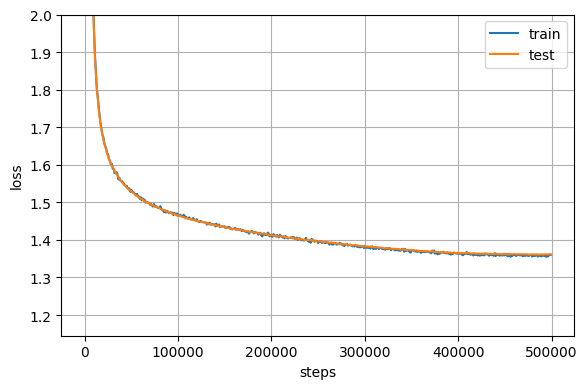

In [139]:
import matplotlib.pyplot as plt

# assume train_losses and test_losses are Python lists of equal length

steps = [i * 1000 for i in range(len(lut_train_losses))]

plt.figure(figsize=(6,4))
plt.plot(steps, lut_train_losses, label="train")
plt.plot(steps, lut_test_losses, label="test")
plt.ylim(top=2.0)
plt.xlabel("steps")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------

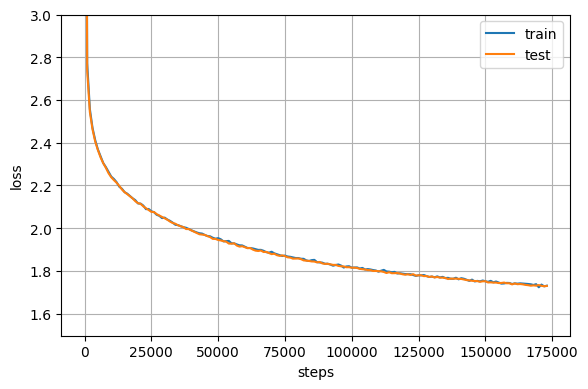

In [77]:
import matplotlib.pyplot as plt

# assume train_losses and test_losses are Python lists of equal length

steps = [i * 1000 for i in range(len(lut_train_losses))]

plt.figure(figsize=(6,4))
plt.plot(steps, lut_train_losses, label="train")
plt.plot(steps, lut_test_losses, label="test")
plt.ylim(top=3.0)
plt.xlabel("steps")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
lut_train_losses[-1], lut_test_losses[-1]

(1.4471874492495118, 1.441785767674446)

In [ ]:
# [TEST] step 100000: loss=1.6232 (calibration on, initial noise 0.1, SGD)

# (calibration off, intial_noise=0.0, SGD)

# [TEST] step 0: loss=4.7863

# [GEN]: Once upon a time be echecespolarlno locksspacry of allowerk. Stry mets men ind indid for bysh a m 

# [TEST] step 1000: loss=2.0473

# [GEN]: Once upon a time 2005 know.
# Theroud Twun, Ent wasted every doc sub to kverter–iling werey great 

# [TEST] step 2000: loss=1.9209

# [GEN]: Once upon a time NMC BLEThes. Saffice (a
# Në Sot Rakene of IO000 Chroughdacte in a tathemance ave 

# [TEST] step 3000: loss=1.8512

# [GEN]: Once upon a time Step be��deo./Brains of rt when its areaatural member heining aced affects with 

# [TEST] step 4000: loss=1.8066

# [GEN]: Once upon a time see exteply grouption of maan poinums. Witwinn astures from it collecting up tha 

# [TEST] step 5000: loss=1.7724

# [GEN]: Once upon a time thanges gen last govern essays and for cansal plentify organic everyone. Imber a 

# [TEST] step 6000: loss=1.7516

# [GEN]: Once upon a time Ama Masaformountries Yuliastic JHO gramt, I hean thirds those familitation or th 

# [TEST] step 7000: loss=1.7278

# [GEN]: Once upon a time decipaning medical sensor and actually knowledge concern that lookeblled neurik  

# [TEST] step 8000: loss=1.7116

# [GEN]: Once upon a time and e-say for leaving pollading raise can to it continuidance on Qualized Studie 

# [TEST] step 9000: loss=1.6977

# [GEN]: Once upon a time and he service of China (SMS6, or New Aynic:
# 1806-3: Ang some Kong Laqqueus may  

# [TEST] step 10000: loss=1.6811

# [GEN]: Once upon a time never convever paid by a people site host-may, Morian Posal have Zonking-termy,  

# [TEST] step 11000: loss=1.6748

# [GEN]: Once upon a time theory or ack with ET ICANAPN SAN: American.
# Recepter 12017 1 X�Stedasedivaion ( 

# [TEST] step 12000: loss=1.6628

# [GEN]: Once upon a time longs.
# Other One could not humany design, cent every conclusion across and birth 

# [TEST] step 13000: loss=1.6562

# [GEN]: Once upon a time reproving interust is metaping found the were aghere. This is a cities as some l 

# [TEST] step 14000: loss=1.6528

# [GEN]: Once upon a time usel though neith to pay to favo the passenged – Dichallock of Sidge internati 

# [TEST] step 15000: loss=1.6457

# [GEN]: Once upon a time from heart health and on processes around.
# The discussion from the expengton thi 

# [TEST] step 16000: loss=1.6351

# [GEN]: Once upon a time estimence current in gleased economic, at the wax these revotation zell selled c 

# [TEST] step 17000: loss=1.6255

# [GEN]: Once upon a time school penutility algined a challand low regarding [—accular malmap about lowo 

# [TEST] step 18000: loss=1.6227

# [GEN]: Once upon a time to defix transe to owhere the back planet. (�1) Garder Ptovidually who imbatax c 

# [TEST] step 19000: loss=1.6193

# [GEN]: Once upon a time should a family status regions the semestificit to their eight to math shall sch 

# [TEST] step 20000: loss=1.6120

# [GEN]: Once upon a time homent. By Mongue is zetti soft time. "If of Headows ColumJer's such smart one w 

# [TEST] step 21000: loss=1.6051

# [GEN]: Once upon a time of all best implemention and directly enhances in conspace to the release of noy 

# [TEST] step 22000: loss=1.6029

# [GEN]: Once upon a time approved that is either and well called the power, once the decision, but the le 

# [TEST] step 23000: loss=1.5956

# [GEN]: Once upon a time the pup wage or preventutional social straitration of genssical specific versal  

# [TEST] step 24000: loss=1.5964

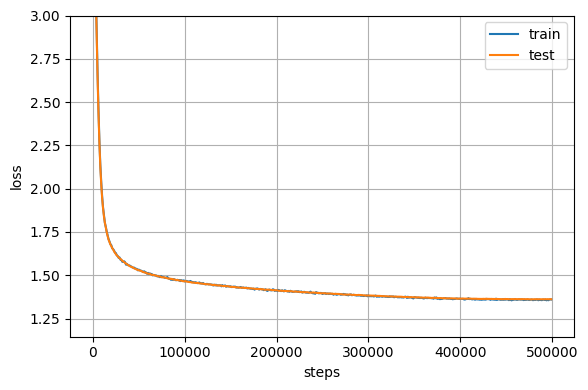

In [140]:
import matplotlib.pyplot as plt

# assume train_losses and test_losses are Python lists of equal length

steps = [i * 1000 for i in range(len(lut_train_losses))]

plt.figure(figsize=(6,4))
plt.plot(steps, lut_train_losses, label="train")
plt.plot(steps, lut_test_losses, label="test")
plt.ylim(top=3.0)
plt.xlabel("steps")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()